# Library

In [1]:
!pip install catboost
!pip install optuna catboost scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.preprocessing import LabelEncoder, StandardScaler
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load dataset

In [3]:
df = pd.read_csv('/content/Student Depression Dataset.csv')

# EDA

**1. Informasi umum**

In [4]:
#info dataset
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

**2. Pengecekan Missing Value**

In [5]:
missing_values = df.isnull().sum()
print(missing_values)

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [6]:
# Menampilkan jumlah missing value
print(missing_values[missing_values > 0])

Financial Stress    3
dtype: int64


**3. Pengecekan Duplikasi Data**

In [7]:
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

Jumlah baris duplikat: 0


**4. Class Balance**

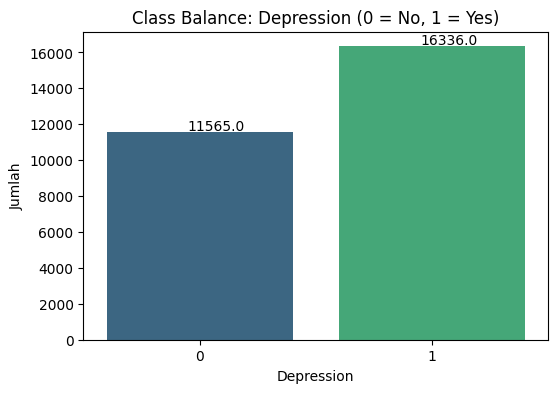

In [8]:
# Mengecek keseimbangan kelas pada kolom target 'Depression'
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Depression', data=df, hue='Depression', palette='viridis', legend=False)
plt.title('Class Balance: Depression (0 = No, 1 = Yes)')
plt.xlabel('Depression')
plt.ylabel('Jumlah')
# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 100))
plt.show()

**5. Sebaran Data**

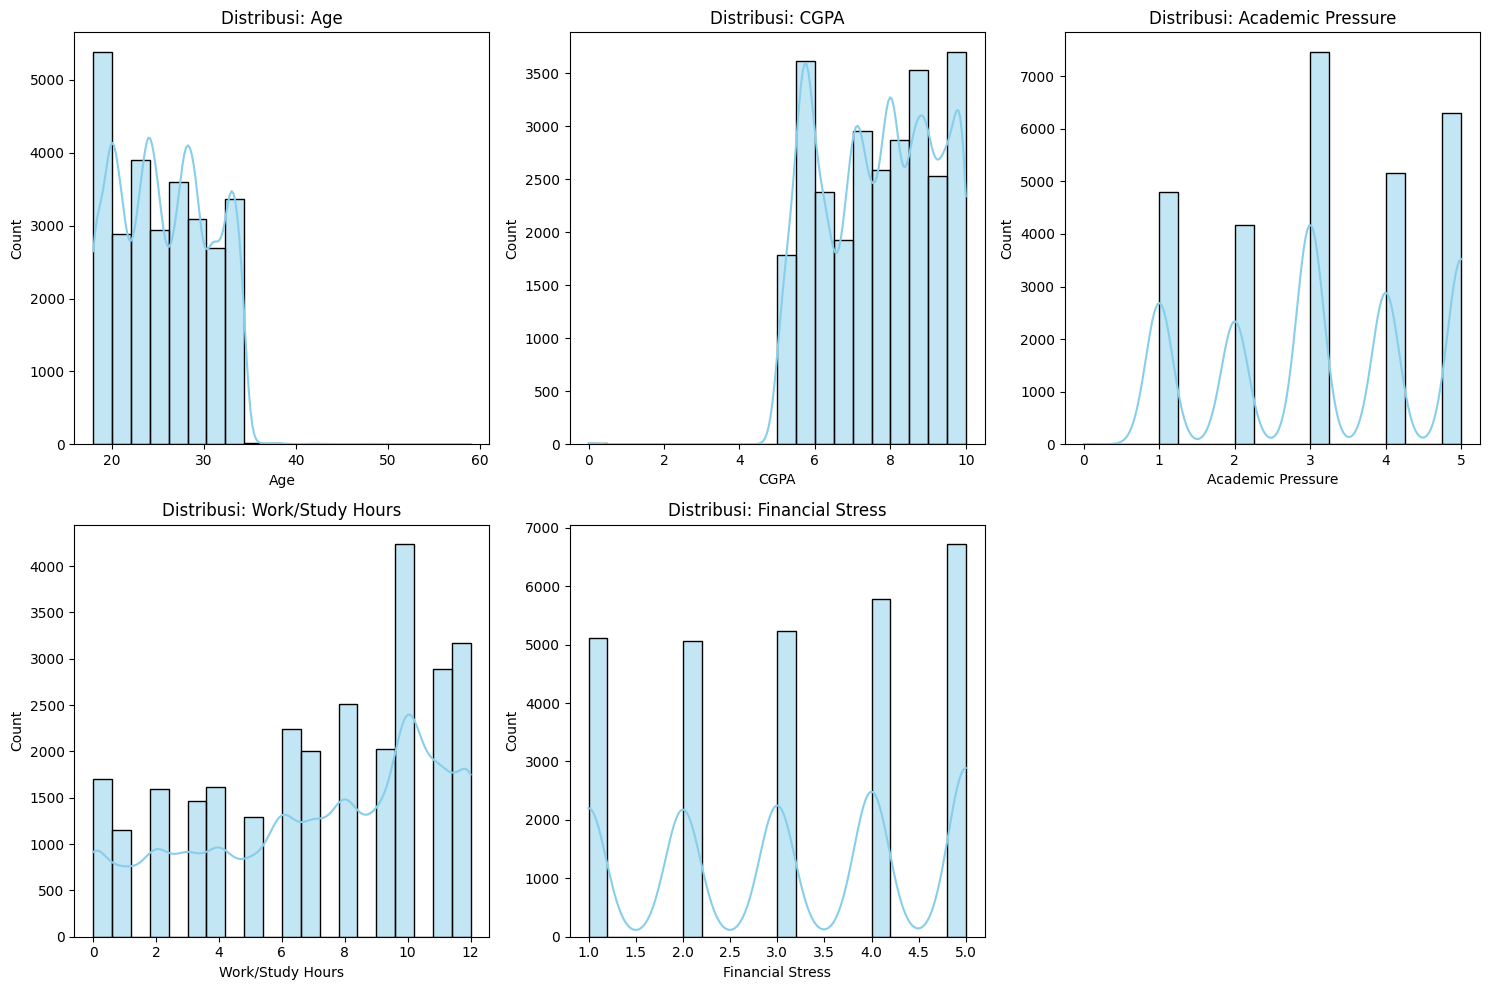

In [9]:
# A. Distribusi Fitur Numerik (Histogram)
# Memilih beberapa kolom numerik penting
num_cols = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribusi: {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

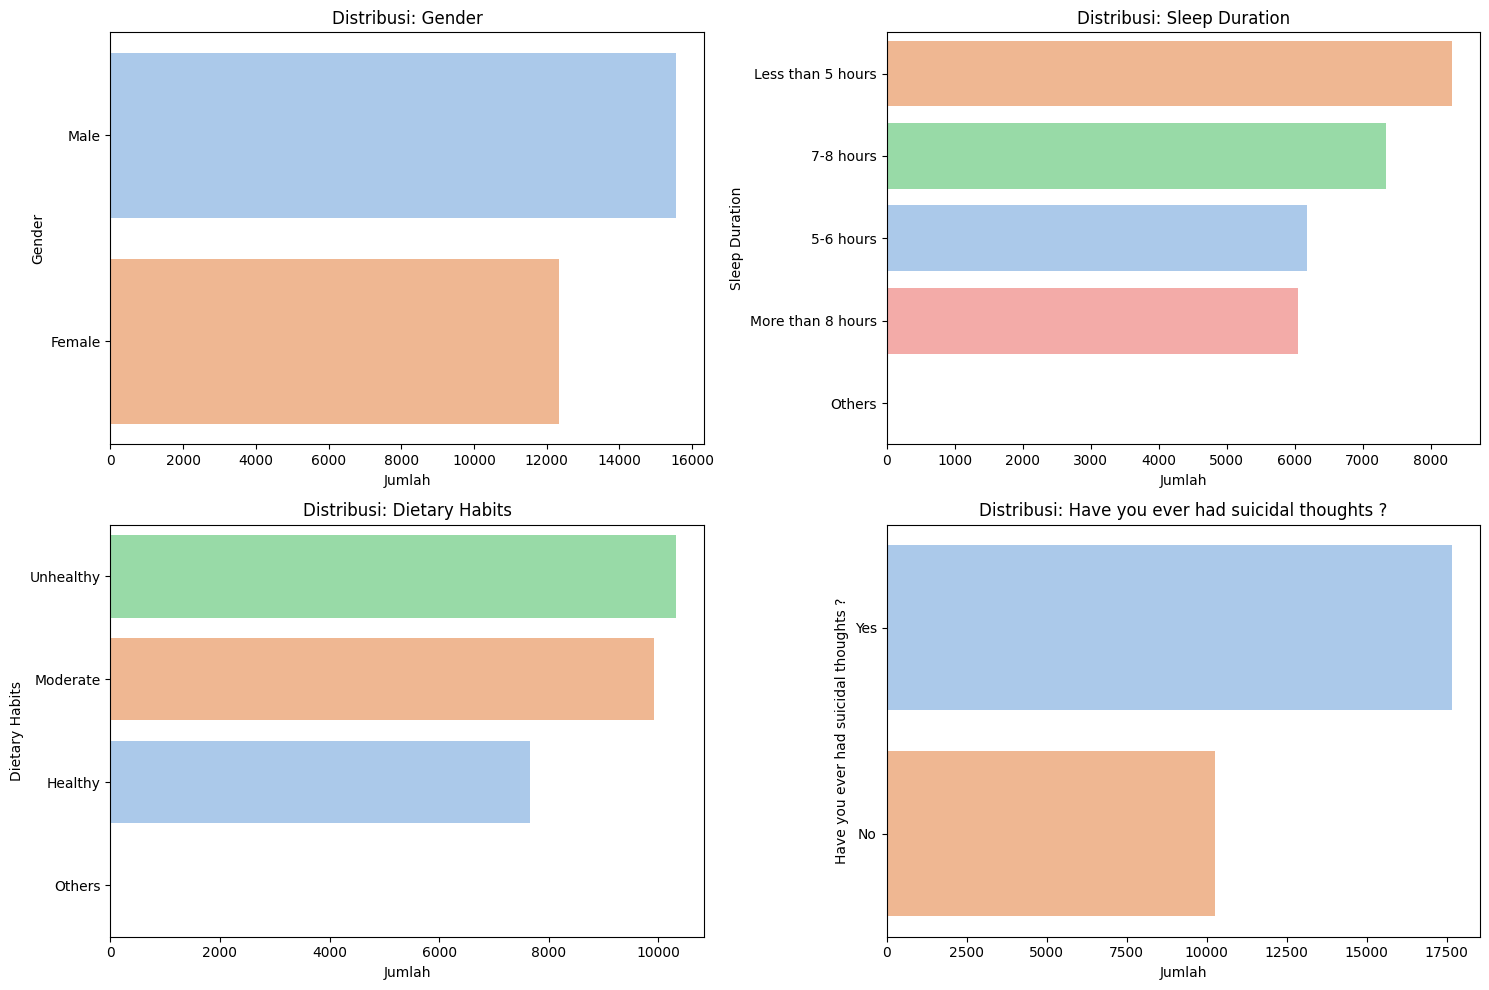

In [10]:
# B. Distribusi Fitur Kategorikal (Bar Chart)
# Memilih beberapa kolom kategorikal penting
cat_cols = ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    # Mengurutkan berdasarkan jumlah terbanyak
    sns.countplot(y=col, data=df, hue=col, palette='pastel', order=df[col].value_counts().index, legend=False)
    plt.title(f'Distribusi: {col}')
    plt.xlabel('Jumlah')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

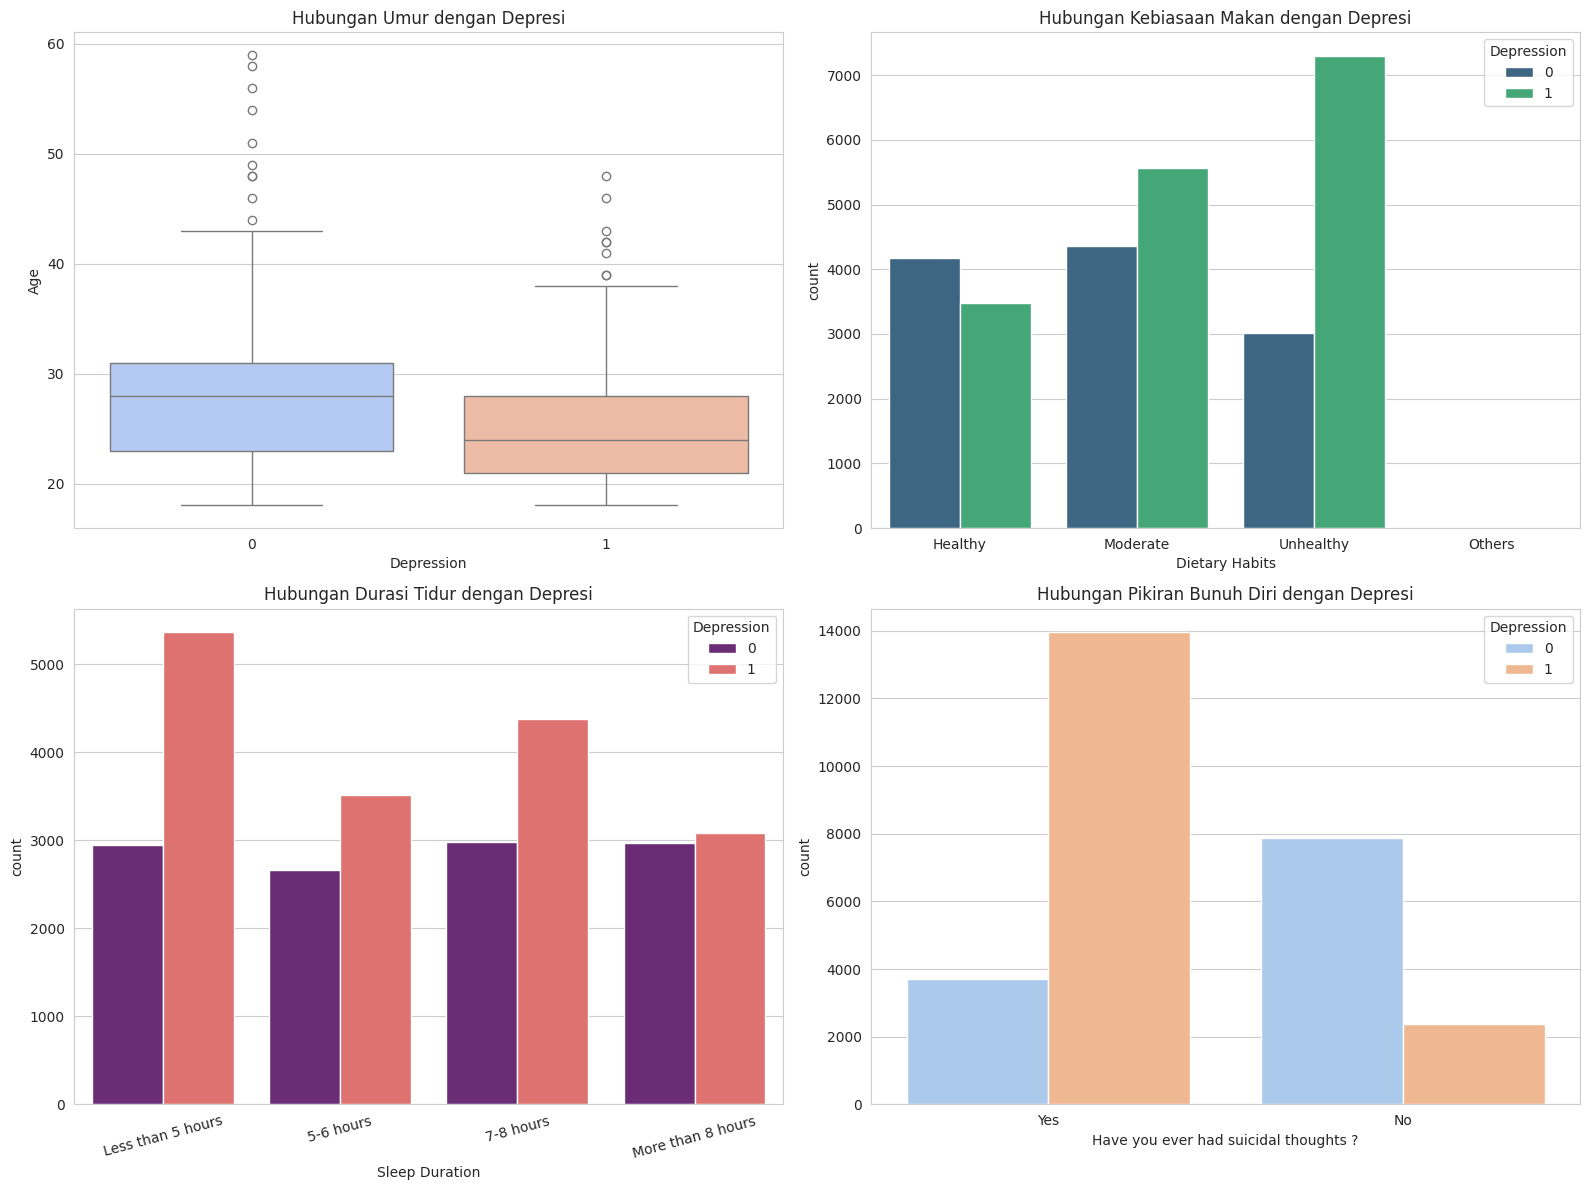

In [11]:
# Setting style plot
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Hubungan Age vs Depression (Boxplot)
# Melihat sebaran umur pada kelompok Depresi vs Tidak
sns.boxplot(ax=axes[0, 0], x='Depression', y='Age', data=df, palette='coolwarm', hue='Depression')
axes[0, 0].set_title('Hubungan Umur dengan Depresi')
if axes[0, 0].legend_: axes[0, 0].legend_.remove() # Hapus legend redundant

# 2. Hubungan Dietary Habits vs Depression
sns.countplot(ax=axes[0, 1], x='Dietary Habits', hue='Depression', data=df, palette='viridis')
axes[0, 1].set_title('Hubungan Kebiasaan Makan dengan Depresi')

# 3. Hubungan Sleep Duration vs Depression
# Mengurutkan kategori tidur agar lebih logis
sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
# Filter order hanya untuk data yang ada (untuk menghindari error jika ada kategori hilang)
existing_sleep = [x for x in sleep_order if x in df['Sleep Duration'].unique()]

sns.countplot(ax=axes[1, 0], x='Sleep Duration', hue='Depression', data=df, order=existing_sleep, palette='magma')
axes[1, 0].set_title('Hubungan Durasi Tidur dengan Depresi')
axes[1, 0].tick_params(axis='x', rotation=15) # Miringkan label agar terbaca

# 4. Hubungan Suicidal Thoughts vs Depression
sns.countplot(ax=axes[1, 1], x='Have you ever had suicidal thoughts ?', hue='Depression', data=df, palette='pastel')
axes[1, 1].set_title('Hubungan Pikiran Bunuh Diri dengan Depresi')

plt.tight_layout()
plt.show()

In [12]:
# --- Tampilkan Analisis Statistik Sederhana ---
print("\n=== INSIGHT DATA ===")
# Rata-rata Umur
print("\n1. Rata-rata Umur:")
print(df.groupby('Depression')['Age'].mean())

# Persentase Depresi berdasarkan Kebiasaan Makan
print("\n2. Persentase Depresi per Kebiasaan Makan:")
print(pd.crosstab(df['Dietary Habits'], df['Depression'], normalize='index') * 100)

# Persentase Depresi berdasarkan Pikiran Bunuh Diri
print("\n3. Persentase Depresi jika memiliki Pikiran Bunuh Diri:")
print(pd.crosstab(df['Have you ever had suicidal thoughts ?'], df['Depression'], normalize='index') * 100)


=== INSIGHT DATA ===

1. Rata-rata Umur:
Depression
0    27.142412
1    24.887733
Name: Age, dtype: float64

2. Persentase Depresi per Kebiasaan Makan:
Depression              0          1
Dietary Habits                      
Healthy         54.607241  45.392759
Moderate        43.977422  56.022578
Others          33.333333  66.666667
Unhealthy       29.272075  70.727925

3. Persentase Depresi jika memiliki Pikiran Bunuh Diri:
Depression                                     0          1
Have you ever had suicidal thoughts ?                      
No                                     76.778917  23.221083
Yes                                    20.950385  79.049615


# Preprocessing

**1. Data cleaning**

In [13]:
# Penanganan Missing Value
df.dropna(inplace=True)
print(df.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [14]:
print("Data Shape setelah cleaning:", df.shape)

Data Shape setelah cleaning: (27898, 18)


**2. Feature Engineering**

In [15]:
def advanced_preprocessing(df):
    data = df.copy()

    # Cleaning Basic
    if 'id' in data.columns:
        data.drop(['id'], axis=1, inplace=True)

    data['Financial Stress'] = data['Financial Stress'].fillna(data['Financial Stress'].mode()[0])

    # Ordinal Encoding (Mapping Manual)
    sleep_map = {'Less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3, 'More than 8 hours': 4, 'Others': 2}
    data['Sleep_Score'] = data['Sleep Duration'].map(sleep_map).fillna(2)

    diet_map = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3, 'Others': 2}
    data['Diet_Score'] = data['Dietary Habits'].map(diet_map).fillna(2)

    # Feature Engineering
    data['Total_Pressure'] = data['Academic Pressure'] + data['Work Pressure'] + data['Financial Stress']
    data['Satisfaction_Index'] = data['Study Satisfaction'] + data['Job Satisfaction']
    data['Stress_Satisfaction_Ratio'] = data['Total_Pressure'] / (data['Satisfaction_Index'] + 1)

    # Binary Encoding
    data['Suicidal_Thoughts'] = data['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0})
    data['Family_History'] = data['Family History of Mental Illness'].map({'Yes': 1, 'No': 0})

    # Hapus kolom asli yang sudah di-encode manual
    data.drop(['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
               'Sleep Duration', 'Dietary Habits'], axis=1, inplace=True)

    return data

In [16]:
df_processed = advanced_preprocessing(df)

# Daftar kolom yang berisi teks (String)
cat_features = ['Gender', 'City', 'Profession', 'Degree']

# Pastikan kolom ini bertipe string
for col in cat_features:
    df_processed[col] = df_processed[col].astype(str)

**4. Split Data**

In [17]:
# Split Data
X = df_processed.drop('Depression', axis=1)
y = df_processed['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {X_train.shape[0]}")
print(f"Jumlah Data Uji  : {X_test.shape[0]}")

Jumlah Data Latih: 25108
Jumlah Data Uji  : 2790


**5. Pemisahan fitur dan target**

In [18]:
# Tampilkan hasil akhir
print("\n--- Hasil setelah pre-processing ---")
print(X.head())


--- Hasil setelah pre-processing ---
   Gender   Age           City Profession  Academic Pressure  Work Pressure  \
0    Male  33.0  Visakhapatnam    Student                5.0            0.0   
1  Female  24.0      Bangalore    Student                2.0            0.0   
2    Male  31.0       Srinagar    Student                3.0            0.0   
3  Female  28.0       Varanasi    Student                3.0            0.0   
4  Female  25.0         Jaipur    Student                4.0            0.0   

   CGPA  Study Satisfaction  Job Satisfaction   Degree  Work/Study Hours  \
0  8.97                 2.0               0.0  B.Pharm               3.0   
1  5.90                 5.0               0.0      BSc               3.0   
2  7.03                 5.0               0.0       BA               9.0   
3  5.59                 2.0               0.0      BCA               4.0   
4  8.13                 3.0               0.0   M.Tech               1.0   

   Financial Stress  Sleep_Sco

# Modelling

**1. CatBoost Classifier**

In [19]:
# Inisialisasi & Training
cb_model = CatBoostClassifier(verbose=0, random_state=42)
cb_model.fit(X_train, y_train, cat_features=cat_features)

# Evaluasi
y_pred = cb_model.predict(X_test)
print("=== Classification Report: CatBoost ===")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc:.4f}")

=== Classification Report: CatBoost ===
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1156
           1       0.87      0.89      0.88      1634

    accuracy                           0.86      2790
   macro avg       0.86      0.85      0.85      2790
weighted avg       0.86      0.86      0.86      2790

Akurasi: 0.8595


# Bayesian Optimization OPTUNA

In [20]:
!pip install optuna catboost scikit-learn pandas

In [21]:
def objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'iterations':1000,
        'loss_function': 'Logloss',
        'eval_metric': 'Accuracy',
        'verbose': False,
        'random_seed': 42
    }

    # Menggunakan Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Bungkus data dengan Pool
        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        val_pool = Pool(X_val, y_val, cat_features=cat_features)

        model = CatBoostClassifier(**params)
        # gunakan early stopping untuk mencegah model melakukan iterasi berlebih
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, verbose=False)

        preds = model.predict(val_pool)
        cv_scores.append(accuracy_score(y_val, preds))

    return np.mean(cv_scores)

In [22]:
# 3. JALANKAN OPTIMASI OPTUNA
# ==========================================
print("\n=== Mulai Proses Tuning dengan Optuna ===")
# Buat studi baru. Direction='maximize' karena kita ingin AKURASI TERTINGGI.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=35, show_progress_bar=True)

print ("\nBest CV Accuracy:", study.best_value)
print ("Best Params:", study.best_params)

[I 2026-05-04 08:56:35,873] A new study created in memory with name: no-name-b919a5c0-5ce2-4a84-a27f-b7d578da81d4



=== Mulai Proses Tuning dengan Optuna ===


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2026-05-04 08:57:18,401] Trial 0 finished with value: 0.8454677213528747 and parameters: {'depth': 7, 'learning_rate': 0.01989596443098989}. Best is trial 0 with value: 0.8454677213528747.
[I 2026-05-04 08:57:46,030] Trial 1 finished with value: 0.8459456106733242 and parameters: {'depth': 10, 'learning_rate': 0.23783342911972252}. Best is trial 1 with value: 0.8459456106733242.
[I 2026-05-04 08:58:06,494] Trial 2 finished with value: 0.8431977649269327 and parameters: {'depth': 6, 'learning_rate': 0.013431897551448675}. Best is trial 1 with value: 0.8459456106733242.
[I 2026-05-04 08:58:35,540] Trial 3 finished with value: 0.8447111141568614 and parameters: {'depth': 9, 'learning_rate': 0.017534758761551944}. Best is trial 1 with value: 0.8459456106733242.
[I 2026-05-04 08:58:50,614] Trial 4 finished with value: 0.848414841655489 and parameters: {'depth': 5, 'learning_rate': 0.2869324099922611}. Best is trial 4 with value: 0.848414841655489.
[I 2026-05-04 08:59:11,627] Trial 5 fini

In [23]:
# 4. HASIL TERBAIK
# ==========================================
print("\n" + "="*50)
print("HASIL OPTIMASI TERBAIK")
print("="*50)
print(f"Akurasi Tertinggi: {study.best_value:.4f}")
print("Parameter Terbaik:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")


HASIL OPTIMASI TERBAIK
Akurasi Tertinggi: 0.8496
Parameter Terbaik:
  - depth: 5
  - learning_rate: 0.11617778851386557


In [24]:
# 5. TRAINING ULANG DENGAN PARAMETER TERBAIK
# ==========================================
print("\n=== Training Final Model dengan Parameter Terbaik ===")
# Ambil parameter terbaik
best_params = study.best_params
best_params['cat_features'] = cat_features
best_params['random_seed'] = 42
best_params['verbose'] = 0

# Latih Model Final
final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train, y_train)


=== Training Final Model dengan Parameter Terbaik ===


CatBoostClassifier(cat_features=['Gender', 'City', 'Profession', 'Degree'], depth=5, learning_rate=0.11617778851386557, random_seed=42, verbose=0)

In [25]:
# Evaluasi Akhir
y_pred_final = final_model.predict(X_test)

# Report
print("=== HASIL AKHIR SETELAH FEATURE ENGINEERING & TUNING ===")
print(f"Akurasi Final: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

=== HASIL AKHIR SETELAH FEATURE ENGINEERING & TUNING ===
Akurasi Final: 0.8609

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1156
           1       0.87      0.89      0.88      1634

    accuracy                           0.86      2790
   macro avg       0.86      0.85      0.86      2790
weighted avg       0.86      0.86      0.86      2790



In [26]:
print("\n--- Membandingkan Baseline vs Tuned ---")

# 1. Baseline Model (Tanpa Tuning)
base_model = CatBoostClassifier(verbose=0, random_state=42)
base_model.fit(X_train, y_train, cat_features=cat_features) # <--- JANGAN LUPA INI

y_pred_base = base_model.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

# 2. Ambil Hasil Model Final (dari langkah sebelumnya)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"Akurasi Baseline (CatBoost) : {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"Akurasi Final (Catboost + Optuna)     : {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"Peningkatan                : +{(acc_final - acc_base)*100:.2f}%")

print("\nClassification Report (Final Tuned Model):")
print(classification_report(y_test, y_pred_final))


--- Membandingkan Baseline vs Tuned ---
Akurasi Baseline (CatBoost) : 0.8595 (85.95%)
Akurasi Final (Catboost + Optuna)     : 0.8609 (86.09%)
Peningkatan                : +0.14%

Classification Report (Final Tuned Model):
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1156
           1       0.87      0.89      0.88      1634

    accuracy                           0.86      2790
   macro avg       0.86      0.85      0.86      2790
weighted avg       0.86      0.86      0.86      2790



In [27]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# 2. Cari Threshold Terbaik
best_threshold = 0.6
best_acc = 0
thresholds = np.arange(0.1, 0.9, 0.002)

for thresh in thresholds:
    # Jika probabilitas > thresh, anggap 1. Jika tidak, 0.
    y_pred_temp = (y_pred_proba > thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_temp)

    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh


In [28]:
# 3. Tampilkan Laporan Akhir dengan Threshold Baru
final_predictions = (y_pred_proba > best_threshold).astype(int)

print("\n" + "="*50)
print("HASIL AKHIR (SETELAH OPTIMASI THRESHOLD)")
print("="*50)
print(f"\n Threshold Terbaik Ditemukan: {best_threshold:.4f}")
print(f"Akurasi Standar (0.50): {accuracy_score(y_test, (y_pred_proba > 0.5).astype(int)):.4f}")
print(f"Akurasi Optimal  ({best_threshold:.2f}): {best_acc:.4f}")
print(classification_report(y_test, final_predictions))


HASIL AKHIR (SETELAH OPTIMASI THRESHOLD)

 Threshold Terbaik Ditemukan: 0.5140
Akurasi Standar (0.50): 0.8609
Akurasi Optimal  (0.51): 0.8624
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1156
           1       0.88      0.89      0.88      1634

    accuracy                           0.86      2790
   macro avg       0.86      0.86      0.86      2790
weighted avg       0.86      0.86      0.86      2790

